<a href="https://colab.research.google.com/github/guneetnagia/LearnML/blob/main/Keras_functional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!wget https://cdn.talentsprint.com/aiml/Experiment_related_data/diabetes.csv

--2026-08-16 07:50:36--  https://cdn.talentsprint.com/aiml/Experiment_related_data/diabetes.csv
Resolving cdn.talentsprint.com (cdn.talentsprint.com)... 172.105.34.236
Connecting to cdn.talentsprint.com (cdn.talentsprint.com)|172.105.34.236|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://cdn.ap-south-1.linodeobjects.com/public_html/aiml/Experiment_related_data/diabetes.csv [following]
--2026-08-16 07:50:37--  https://cdn.ap-south-1.linodeobjects.com/public_html/aiml/Experiment_related_data/diabetes.csv
Resolving cdn.ap-south-1.linodeobjects.com (cdn.ap-south-1.linodeobjects.com)... 139.162.24.106, 172.105.116.53, 172.104.188.5, ...
Connecting to cdn.ap-south-1.linodeobjects.com (cdn.ap-south-1.linodeobjects.com)|139.162.24.106|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/csv]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K   147KB/s    in 0.2s    

2026-08

In [3]:
import pandas as pd
file_path = 'diabetes.csv'

In [4]:
data=pd.read_csv(file_path)
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
X = data.drop(columns=['Outcome', 'BMI'])
y = data.Outcome

In [6]:
y_classification = data.Outcome
y_regression = data.BMI

In [11]:
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
input_layer = Input(shape=(7,))

In [12]:
l1 = Dense(8, activation='relu')(input_layer)
l2 = Dense(10, activation='relu')(l1)
l3 = Dense(10, activation='relu')(l2)

In [32]:
output_1 = Dense(1, activation='sigmoid', name="classification_output")(l3)
output_2 = Dense(1, activation='linear', name="regression_output")(l3)

In [33]:
model = Model(inputs = input_layer, outputs=[output_1, output_2])

In [34]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │         64 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │         90 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │        110 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classification_out… │ (None, 1)         │         11 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ regression_output   │ (None, 1)         │         11 │ dense_3[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 286 (1.12 KB)

 Trainable params: 286 (1.12 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(optimizer='adam', loss={'classification_output':'binary_crossentropy', 'regression_output':'mse'}, metrics={'classification_output':'accuracy', 'regression_output':'mae'})

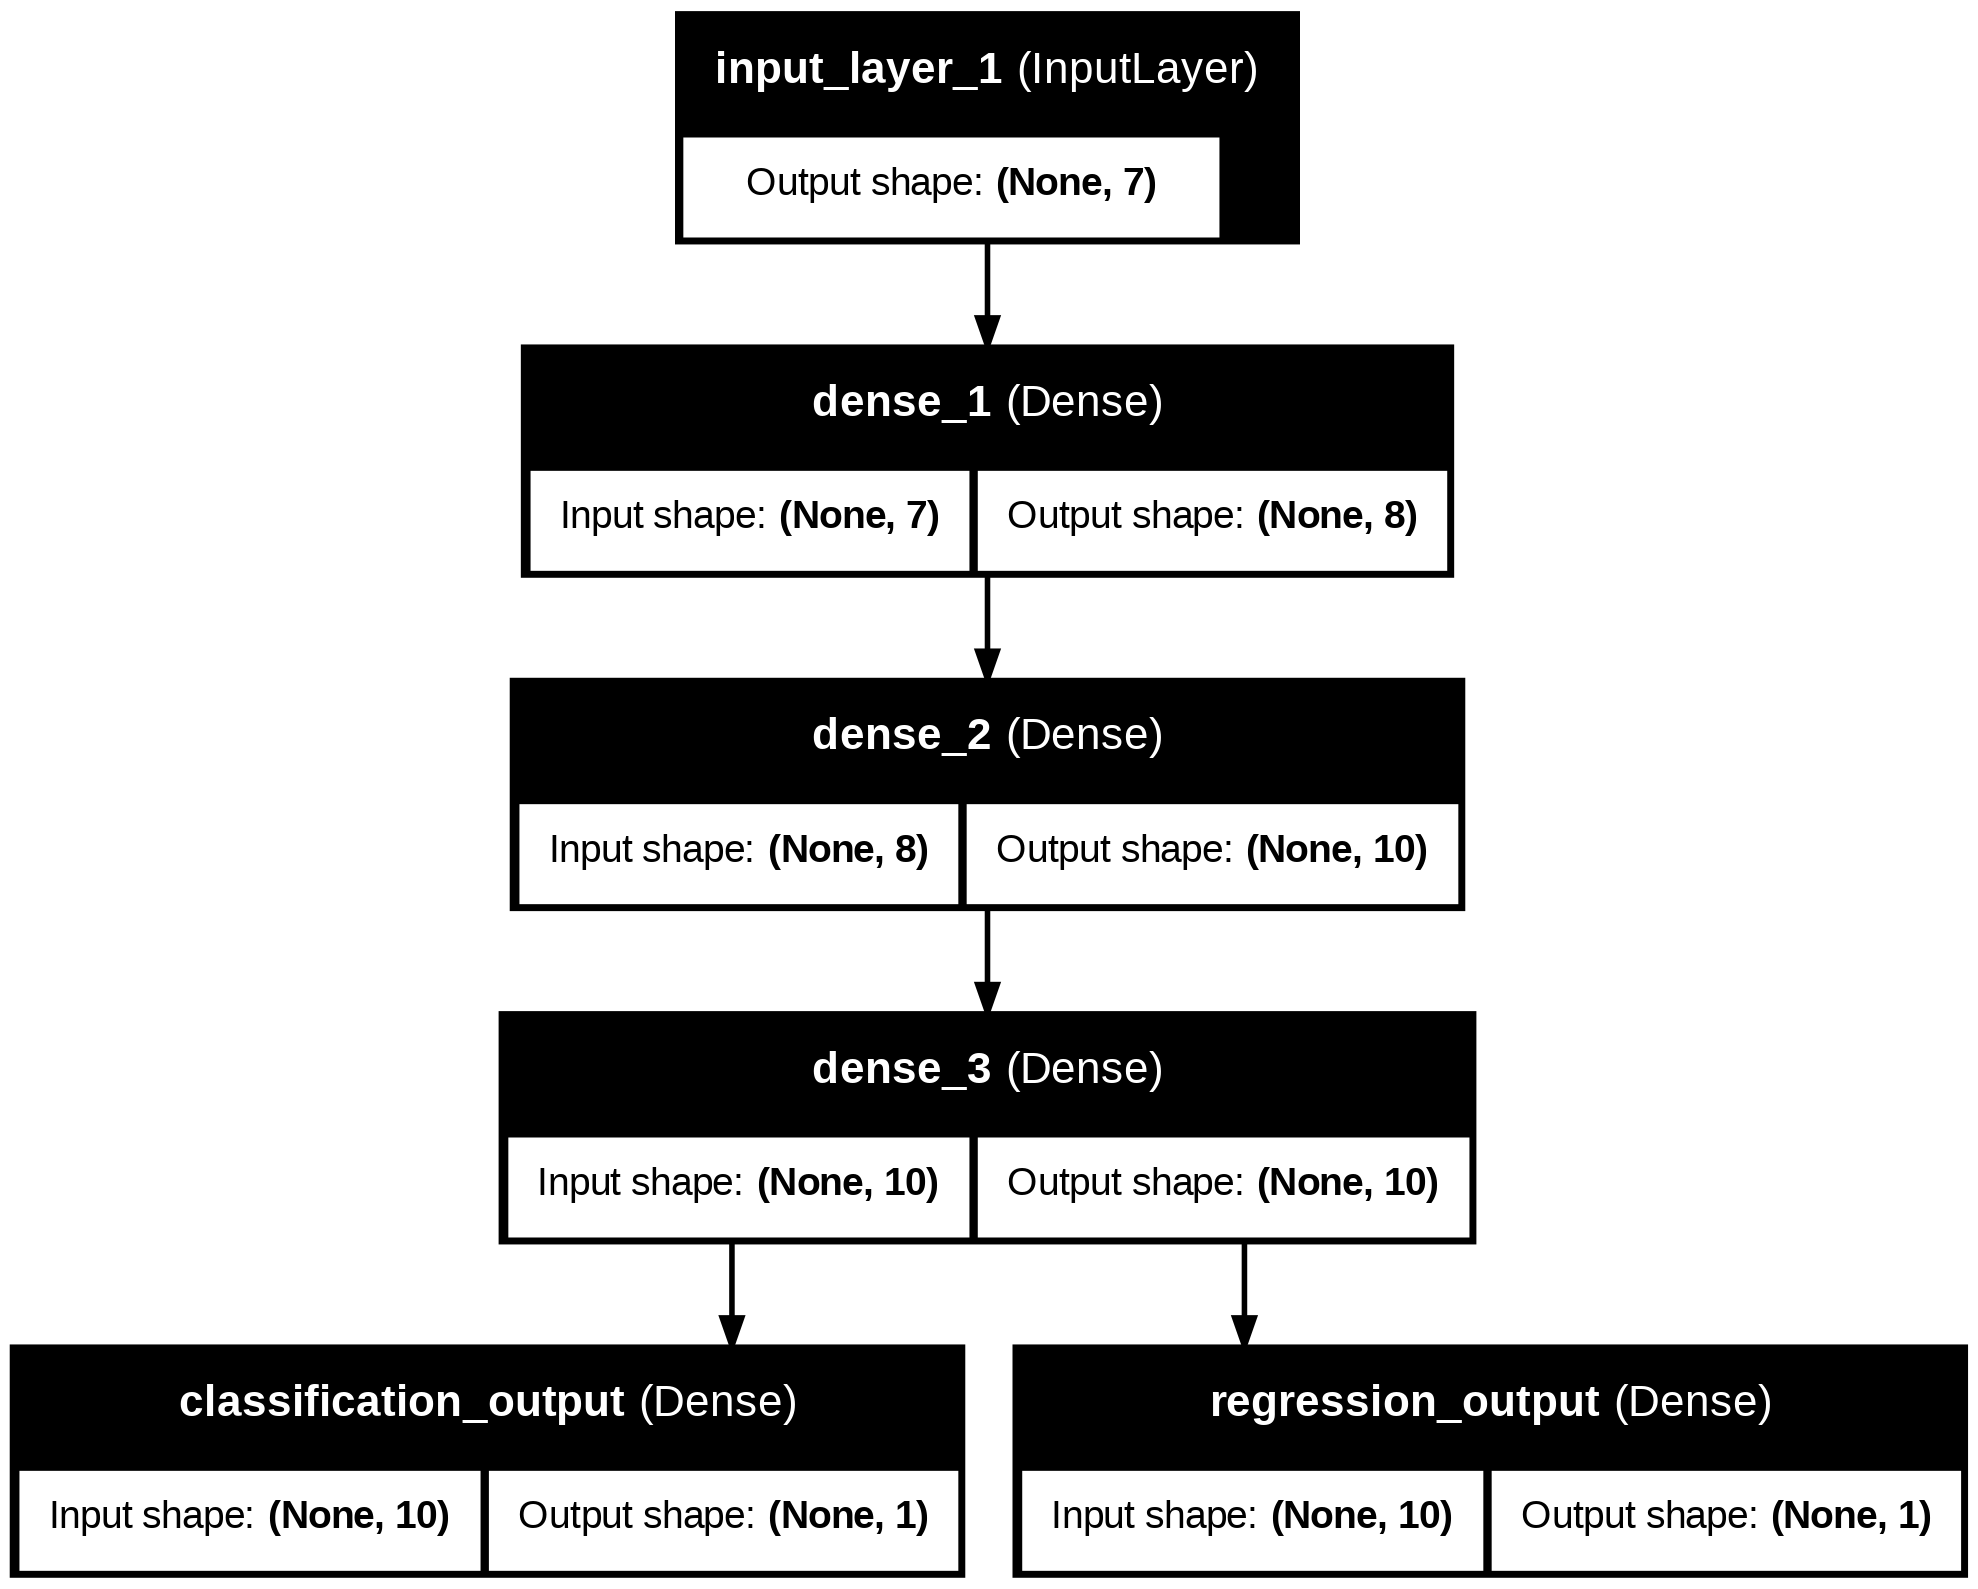

In [36]:
from tensorflow.keras.utils import plot_model
plot_model(model, to_file="model_with_two_predictions.png", show_shapes=True, show_layer_names=True)

In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train_classification, y_test_classification, y_train_regression, y_test_regression = train_test_split(
    X, y_classification, y_regression, test_size=0.2, random_state=42)

history = model.fit(X_train,
                    {'classification_output': y_train_classification,'regression_output':y_train_regression},
                    validation_data=(X_test, {'classification_output':y_test_classification, 'regression_output':y_test_regression}),
                    epochs=50, batch_size=32)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - classification_output_accuracy: 0.3469 - classification_output_loss: 4.8681 - loss: 1044.9089 - regression_output_loss: 1045.3846 - regression_output_mae: 31.3376 - val_classification_output_accuracy: 0.3571 - val_classification_output_loss: 4.9298 - val_loss: 968.8892 - val_regression_output_loss: 963.7316 - val_regression_output_mae: 29.9904
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - classification_output_accuracy: 0.3469 - classification_output_loss: 4.9518 - loss: 873.6667 - regression_output_loss: 870.0094 - regression_output_mae: 28.5328 - val_classification_output_accuracy: 0.3571 - val_classification_output_loss: 4.9188 - val_loss: 793.6008 - val_regression_output_loss: 788.4052 - val_regression_output_mae: 26.9604
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - classification_output_accuracy: 0.3469 - classification_output_loss: 5.0314 - loss: 693.0752 - regression_output_loss: 682.9173 - regression_output_mae

In [38]:
predictions = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [39]:
classification_predictions = (predictions[0] > 0.5).astype(int)
regression_predictions = predictions[1]

In [42]:
result = pd.DataFrame({
    'true_classification':y_test_classification,
    'prediction_classification':classification_predictions.flatten(),
    'true_regression':y_test_regression,
    'prediction_regression':regression_predictions.flatten()
})

In [43]:
result

,true_classification,prediction_classification,true_regression,prediction_regression
668,0,0,34.0,29.710413
324,0,0,35.7,33.529976
624,0,0,30.8,24.961887
690,0,0,24.6,28.495602
473,0,0,29.9,33.850929
...,...,...,...,...
355,1,0,30.4,36.683502
534,0,0,33.3,26.032358
344,0,0,36.8,27.111898
296,1,0,28.0,35.468327
